In [22]:
!pip install Sastrawi tqdm
!pip install wordcloud

import pandas as pd
import re
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
df = pd.read_csv('ulasan_pln_mobile.csv')

print("Total data awal:", len(df))

Total data awal: 171000



Distribusi rating awal:
score
5    145527
1     14711
4      4128
3      3642
2      2992
Name: count, dtype: int64


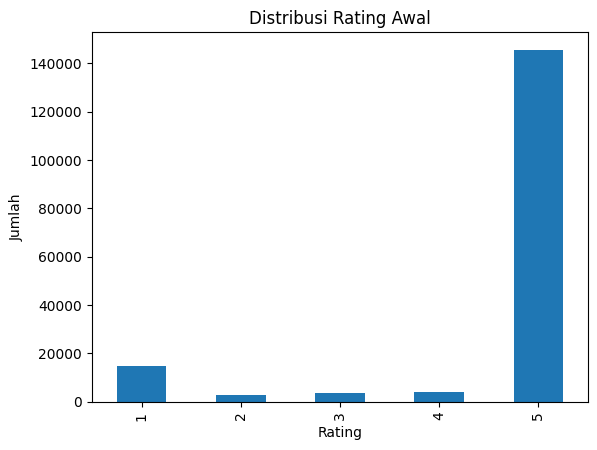

In [24]:
print("\nDistribusi rating awal:")
print(df['score'].value_counts())

plt.figure()
df['score'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribusi Rating Awal")
plt.xlabel("Rating")
plt.ylabel("Jumlah")
plt.savefig("distribusi_rating_awal.png")
plt.show()

In [25]:
def label(score):
    if score == 5:
        return 'positive'
    elif score <= 2:
        return 'negative'
    else:
        return None

df['label'] = df['score'].apply(label)
df = df.dropna(subset=['label'])

print("Setelah filter rating:", len(df))

Setelah filter rating: 163230


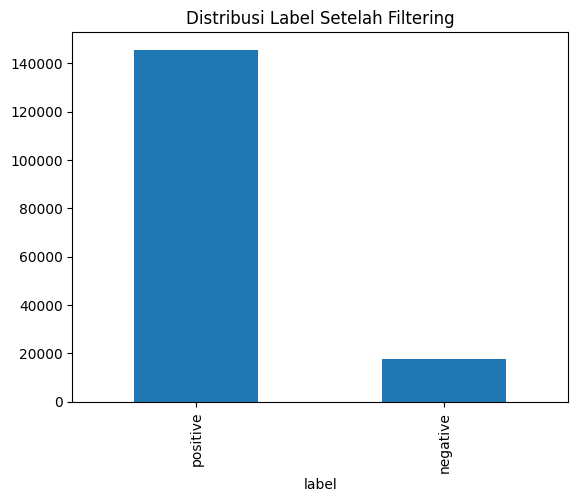

In [26]:
plt.figure()
df['label'].value_counts().plot(kind='bar')
plt.title("Distribusi Label Setelah Filtering")
plt.savefig("label_setelah_filter.png")
plt.show()

In [27]:
df_pos = df[df['label'] == 'positive']
df_neg = df[df['label'] == 'negative']

n = min(len(df_pos), len(df_neg))

df_pos_sample = df_pos.sample(n, random_state=42)
df_neg_sample = df_neg.sample(n, random_state=42)

df = pd.concat([df_pos_sample, df_neg_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Setelah balancing:")
print(df['label'].value_counts())

Setelah balancing:
label
negative    17703
positive    17703
Name: count, dtype: int64


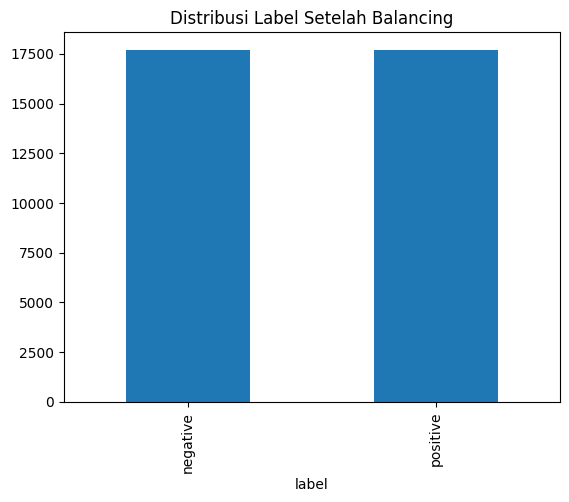

In [28]:
plt.figure()
df['label'].value_counts().plot(kind='bar')
plt.title("Distribusi Label Setelah Balancing")
plt.savefig("label_setelah_balancing.png")
plt.show()

In [29]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stopwords_id = set(stopwords.words('indonesian'))

# jangan hapus negasi
negation_words = {'tidak', 'tak', 'gak', 'ga', 'nggak', 'kurang'}
stopwords_id = stopwords_id - negation_words

def cleaning(text):
    text = re.sub(r'http\S+', '', str(text))
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower().strip()

# HANDLE NEGASI
def handle_negation(text):
    return re.sub(r'\b(tidak|tak|gak|ga|nggak|kurang)\s+(\w+)', r'\1_\2', text)

# HANDLE INTENSIFIER
def handle_intensifier(text):
    return re.sub(r'\b(sangat|banget|sekali)\s+(\w+)', r'\1_\2', text)

def preprocess(text):
    text = cleaning(text)
    text = handle_negation(text)
    text = handle_intensifier(text)

    tokens = text.split()
    tokens = [w for w in tokens if w not in stopwords_id]
    tokens = [stemmer.stem(w) for w in tokens]

    return ' '.join(tokens)

print("\nMulai preprocessing...")
tqdm.pandas()
df['text_final'] = df['content'].progress_apply(preprocess)


Mulai preprocessing...


100%|██████████| 35406/35406 [31:05<00:00, 18.98it/s]


In [30]:
df[['content', 'text_final', 'label']].to_csv('hasil_preprocessing.csv', index=False)
print(" Hasil preprocessing disimpan!")

 Hasil preprocessing disimpan!


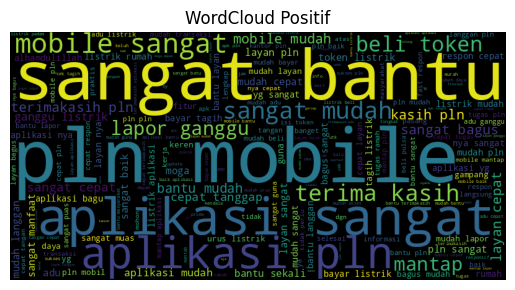

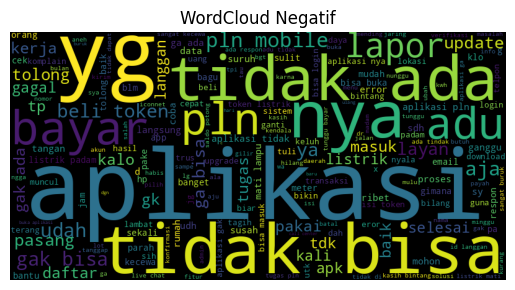

In [31]:
text_pos = ' '.join(df[df['label'] == 'positive']['text_final'])
text_neg = ' '.join(df[df['label'] == 'negative']['text_final'])

# Positif
wc_pos = WordCloud(width=800, height=400).generate(text_pos)
plt.figure()
plt.imshow(wc_pos)
plt.axis('off')
plt.title("WordCloud Positif")
plt.savefig("wordcloud_positif.png")
plt.show()

# Negatif
wc_neg = WordCloud(width=800, height=400).generate(text_neg)
plt.figure()
plt.imshow(wc_neg)
plt.axis('off')
plt.title("WordCloud Negatif")
plt.savefig("wordcloud_negatif.png")
plt.show()

In [32]:
vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85,
    binary=True
)

X = vectorizer.fit_transform(df['text_final'])
y = df['label']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train, y_train)

MultinomialNB(alpha=0.1)

In [35]:
y_pred = nb.predict(X_test)

print("\n=== HASIL MODEL ===")
print("Akurasi:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== HASIL MODEL ===
Akurasi: 0.953120587404688

Classification Report:
              precision    recall  f1-score   support

    negative       0.93      0.98      0.95      3541
    positive       0.97      0.93      0.95      3541

    accuracy                           0.95      7082
   macro avg       0.95      0.95      0.95      7082
weighted avg       0.95      0.95      0.95      7082


Confusion Matrix:
[[3454   87]
 [ 245 3296]]


In [36]:
import pickle

with open('model_nb_pln.pkl', 'wb') as f:
    pickle.dump(nb, f)

with open('vectorizer_pln.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("\nModel berhasil disimpan!")


Model berhasil disimpan!


In [37]:
def predict_text(text):
    text = preprocess(text)
    vec = vectorizer.transform([text])
    return nb.predict(vec)[0]

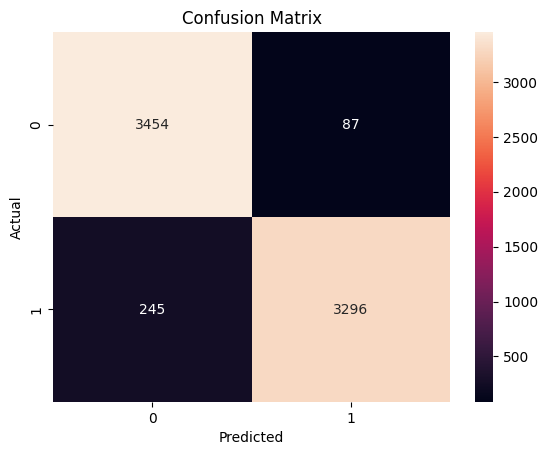

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")
plt.show()

In [39]:
print("\n=== TEST MANUAL ===")
print("tidak bagus →", predict_text("tidak bagus"))
print("bagus sekali →", predict_text("bagus sekali"))
print("kurang bagus →", predict_text("kurang bagus"))
print("aplikasi jelek banget →", predict_text("aplikasi jelek banget"))
print("fiturnya sangat membantu →", predict_text("fiturnya sangat membantu"))


=== TEST MANUAL ===
tidak bagus → negative
bagus sekali → positive
kurang bagus → negative
aplikasi jelek banget → negative
fiturnya sangat membantu → positive
